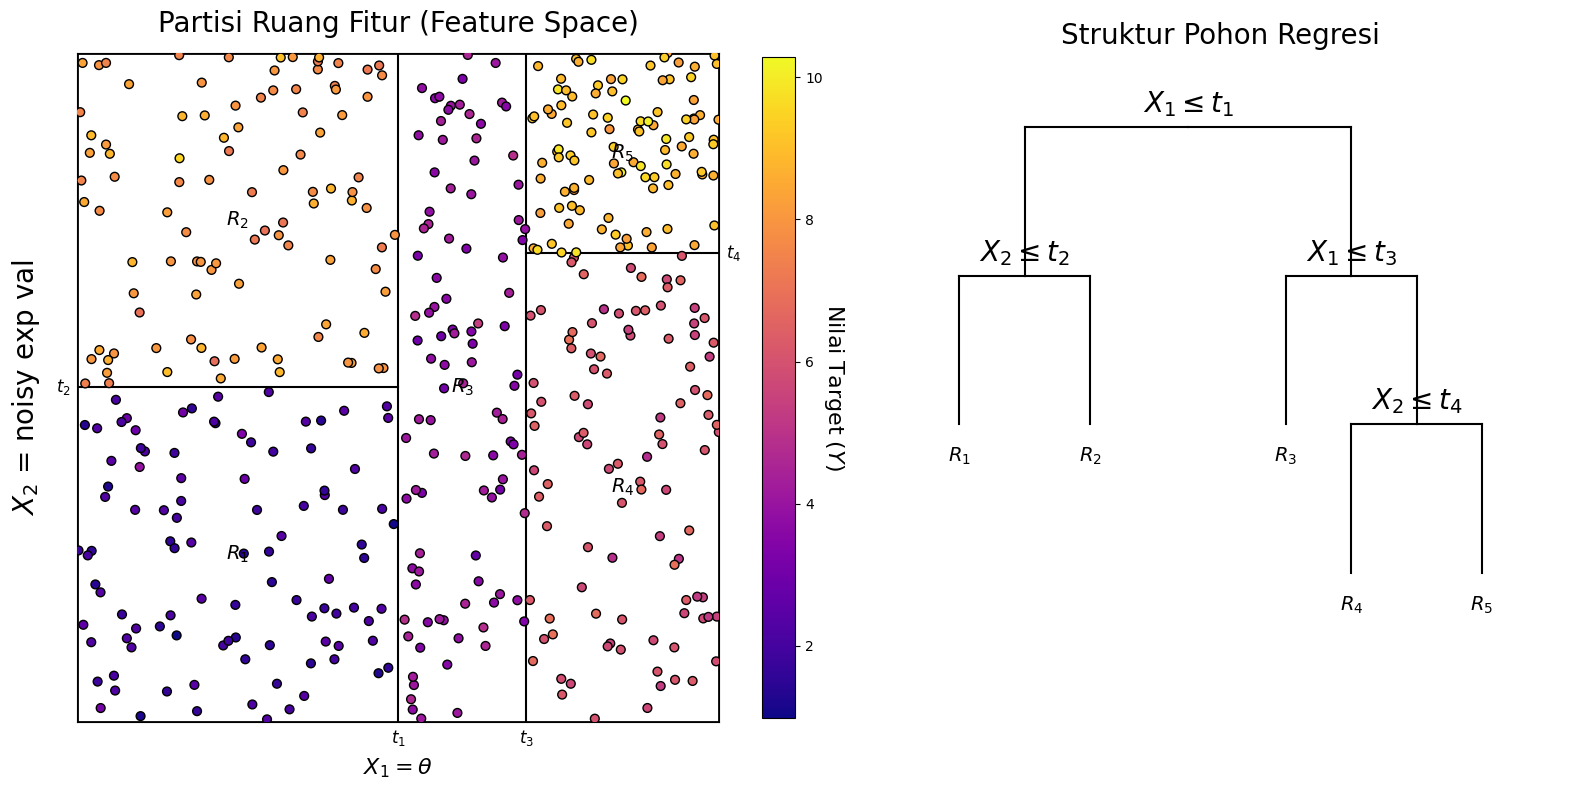

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# 1. Konfigurasi Data Dummy & Wilayah
np.random.seed(42)

def generate_points(x_range, y_range, value_mean, n=100):
    x = np.random.uniform(x_range[0], x_range[1], n)
    y = np.random.uniform(y_range[0], y_range[1], n)
    values = np.random.normal(value_mean, 0.5, n) 
    return x, y, values

# Definisi batas cutpoint (t1..t4)
t1 = 5.0
t2 = 5.0
t3 = 7.0
t4 = 7.0

# Generate data
data_r1 = generate_points((0, t1), (0, t2), value_mean=2)    # R1
data_r2 = generate_points((0, t1), (t2, 10), value_mean=8)   # R2
data_r3 = generate_points((t1, t3), (0, 10), value_mean=4)   # R3
data_r4 = generate_points((t3, 10), (0, t4), value_mean=6)   # R4
data_r5 = generate_points((t3, 10), (t4, 10), value_mean=9)  # R5

all_x = np.concatenate([data_r1[0], data_r2[0], data_r3[0], data_r4[0], data_r5[0]])
all_y = np.concatenate([data_r1[1], data_r2[1], data_r3[1], data_r4[1], data_r5[1]])
all_v = np.concatenate([data_r1[2], data_r2[2], data_r3[2], data_r4[2], data_r5[2]])

# ==========================================
# PLOTTING
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# --- GAMBAR 1: PARTISI RUANG FITUR (KIRI) ---

# Plot titik data
sc = ax1.scatter(all_x, all_y, c=all_v, cmap='plasma', edgecolors='k', s=40, zorder=3)

# === TAMBAHAN: COLOR BAR ===
# fraction=0.046 dan pad=0.04 adalah trik agar tinggi colorbar pas dengan plot
cbar = fig.colorbar(sc, ax=ax1, fraction=0.046, pad=0.06)
cbar.set_label(r'Nilai Target ($Y$)', rotation=270, labelpad=17, fontsize=16)

# Gambar Garis Pembatas
# t1 (Vertical utama)
ax1.plot([t1, t1], [0, 10], 'k-', lw=1.5)
# Text t1 ditempelkan dekat sumbu (y=-0.3), va='top' supaya menggantung pas di bawah garis
ax1.text(t1, -0.1, r'$t_1$', ha='center', va='top', fontsize=12) 

# t2 (Horizontal di kiri)
ax1.plot([0, t1], [t2, t2], 'k-', lw=1.5)
# Text t2 ditempelkan dekat sumbu kiri (x=-0.2), ha='right'
ax1.text(-0.1, t2, r'$t_2$', va='center', ha='right', fontsize=12)

# t3 (Vertical di kanan)
ax1.plot([t3, t3], [0, 10], 'k-', lw=1.5)
ax1.text(t3, -0.1, r'$t_3$', ha='center', va='top', fontsize=12)

# t4 (Horizontal di kanan)
ax1.plot([t3, 10], [t4, t4], 'k-', lw=1.5)
# Text t4 di sisi kanan luar
ax1.text(10.1, t4, r'$t_4$', va='center', ha='left', fontsize=12)

# Label Region
ax1.text(t1/2, t2/2, r'$R_1$', fontsize=14, ha='center', va='center', fontweight='bold')
ax1.text(t1/2, t2 + (10-t2)/2, r'$R_2$', fontsize=14, ha='center', va='center', fontweight='bold')
ax1.text(t1 + (t3-t1)/2, 5, r'$R_3$', fontsize=14, ha='center', va='center', fontweight='bold')
ax1.text(t3 + (10-t3)/2, t4/2, r'$R_4$', fontsize=14, ha='center', va='center', fontweight='bold')
ax1.text(t3 + (10-t3)/2, t4 + (10-t4)/2, r'$R_5$', fontsize=14, ha='center', va='center', fontweight='bold')

# Dekorasi Ax1
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)

# LABELPAD diperbesar (30) supaya X1 dan X2 menjauh dan memberi ruang untuk t1, t2
ax1.set_xlabel(r'$X_1 = \theta$', fontsize=16, labelpad=25) 
ax1.set_ylabel(r'$X_2$ = noisy exp val', fontsize=20, labelpad=25)

ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_title('Partisi Ruang Fitur (Feature Space)', fontsize=20, pad=15)

rect = patches.Rectangle((0,0), 10, 10, linewidth=2, edgecolor='black', facecolor='none')
ax1.add_patch(rect)


# --- GAMBAR 2: POHON KEPUTUSAN (KANAN) ---

root = (5, 9)
l1_left = (2.5, 7)
l1_right = (7.5, 7)
l2_left_left = (1.5, 5)   
l2_left_right = (3.5, 5)  
l2_right_left = (6.5, 5)  
l2_right_right = (8.5, 5) 
l3_right_left = (7.5, 3) 
l3_right_right = (9.5, 3) 

# Edges
ax2.plot([root[0], l1_left[0]], [root[1], root[1]], 'k-') 
ax2.plot([l1_left[0], l1_left[0]], [root[1], l1_left[1]], 'k-') 
ax2.plot([root[0], l1_right[0]], [root[1], root[1]], 'k-') 
ax2.plot([l1_right[0], l1_right[0]], [root[1], l1_right[1]], 'k-') 
ax2.text(root[0], root[1]+0.2, r'$X_1 \leq t_1$', ha='center', fontsize=20) 

ax2.plot([l1_left[0], l2_left_left[0]], [l1_left[1], l1_left[1]], 'k-')
ax2.plot([l2_left_left[0], l2_left_left[0]], [l1_left[1], l2_left_left[1]], 'k-') 
ax2.plot([l1_left[0], l2_left_right[0]], [l1_left[1], l1_left[1]], 'k-')
ax2.plot([l2_left_right[0], l2_left_right[0]], [l1_left[1], l2_left_right[1]], 'k-') 
ax2.text(l1_left[0], l1_left[1]+0.2, r'$X_2 \leq t_2$', ha='center', fontsize=20)

ax2.plot([l1_right[0], l2_right_left[0]], [l1_right[1], l1_right[1]], 'k-')
ax2.plot([l2_right_left[0], l2_right_left[0]], [l1_right[1], l2_right_left[1]], 'k-') 
ax2.plot([l1_right[0], l2_right_right[0]], [l1_right[1], l1_right[1]], 'k-')
ax2.plot([l2_right_right[0], l2_right_right[0]], [l1_right[1], l2_right_right[1]], 'k-') 
ax2.text(l1_right[0], l1_right[1]+0.2, r'$X_1 \leq t_3$', ha='center', fontsize=20)

ax2.plot([l2_right_right[0], l3_right_left[0]], [l2_right_right[1], l2_right_right[1]], 'k-')
ax2.plot([l3_right_left[0], l3_right_left[0]], [l2_right_right[1], l3_right_left[1]], 'k-') 
ax2.plot([l2_right_right[0], l3_right_right[0]], [l2_right_right[1], l2_right_right[1]], 'k-')
ax2.plot([l3_right_right[0], l3_right_right[0]], [l2_right_right[1], l3_right_right[1]], 'k-') 
ax2.text(l2_right_right[0], l2_right_right[1]+0.2, r'$X_2 \leq t_4$', ha='center', fontsize=20)

# Terminal Nodes
ax2.text(l2_left_left[0], l2_left_left[1]-0.5, r'$R_1$', fontsize=14, ha='center', fontweight='bold')
ax2.text(l2_left_right[0], l2_left_right[1]-0.5, r'$R_2$', fontsize=14, ha='center', fontweight='bold')
ax2.text(l2_right_left[0], l2_right_left[1]-0.5, r'$R_3$', fontsize=14, ha='center', fontweight='bold')
ax2.text(l3_right_left[0], l3_right_left[1]-0.5, r'$R_4$', fontsize=14, ha='center', fontweight='bold')
ax2.text(l3_right_right[0], l3_right_right[1]-0.5, r'$R_5$', fontsize=14, ha='center', fontweight='bold')

ax2.set_xlim(0, 11)
ax2.set_ylim(1, 10)
ax2.axis('off')
ax2.set_title('Struktur Pohon Regresi', fontsize=20)

plt.tight_layout()
plt.show()